In [ ]:
import pandas as pd
from datetime import datetime, timedelta

import solarsystem
print('solarsystem version:',solarsystem.__version__)
from skyfield.api import load, wgs84
from skyfield import almanac

from skyfield.api import N, S, E, W, load, wgs84


solarsystem version: 0.1.8


In [ ]:
N, S, E, W

(1.0, -1.0, 1.0, -1.0)

In [ ]:
import math
from solarsystem.functions import normalize, spherical_ecliptic2equatorial
from solarsystem.functions import precession_longitude_correction, spherical_equatorial2ecliptic

In [ ]:
# --------------------------------------------------
# HELPERS
# --------------------------------------------------

def minutes_abs_difference(t1, t2):
    """Return absolute time difference in minutes."""
    return abs((t1 - t2).total_seconds()) / 60.0
def minutes_difference(t1, t2):
    """Return time difference in minutes."""
    return ((t1 - t2).total_seconds()) / 60.0

## MOONRISE - MOONSET

In [ ]:

# --------------------------------------------------
# USER CONFIGURATION
# --------------------------------------------------

LATITUDE = 51.4934      # Greenwich
LONGITUDE = 0.0098
NORTH=True
EAST=True

LATITUDE = 37.98      # Athens
LONGITUDE = 23.73

NORTH=True # set to False for South Longitudes
EAST=True # set to False fot West Latitudes


YEAR = 2025
MONTH = 1
DAY = 1

# number of validation days
N_DAYS = 365




In [ ]:

if NORTH==False:
    LATITUDE *= -1
if EAST==False:
    LONGITUDE *= -1

In [ ]:
YEAR, MONTH, DAY

(2025, 1, 1)

In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY FOR A SINGLE YEAR
#    MOONRISE - MOONSET & MOON ILUMINATION
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------


# --------------------------------------------------
# SKYFIELD SETUP
# --------------------------------------------------

ts = load.timescale()
eph = load("de440.bsp")
# eph = load("de440s.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]


results = []

for i in range(N_DAYS):

    date = datetime(YEAR, MONTH, DAY) + timedelta(days=i)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================
    ss_moon = solarsystem.Moon(year=y, month=m, day=d, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)

    ss_illum = ss_moon.phase()
    ss_moonrise, ss_moonset = ss_moon.moonriseset()

    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)


    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    # bluffton = wgs84.latlon(LATITUDE * N, LONGITUDE * E)
    location = wgs84.latlon(LATITUDE , LONGITUDE )
    # bluffton = wgs84.latlon(LATITUDE , LONGITUDE, elevation_m=-6500000 )

    observer = eph['Earth'] + location


    moon = eph['Moon']
    t0 = ts.utc(y, m, d-1)
    t1 = ts.utc(y, m, d+1)
    # t0 = ts.utc(y, m, d)-timedelta(days=1)
    # t1 = ts.utc(y, m, d)+timedelta(days=1)

    t, y0 = almanac.find_risings(observer, moon, t0, t1)
    # print('Moonrises (UTC):', t.utc_iso(' '))

    if len(t.utc_strftime())==2:
        sf_moonrise = t.utc_strftime()[1][:-4]
    else:
        sf_moonrise = t.utc_strftime()[0][:-4]

    sf_moonrise=datetime.strptime(sf_moonrise, "%Y-%m-%d %H:%M:%S")

    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d)+timedelta(days=2)
    t, y0 = almanac.find_settings(observer, moon, t0, t1)
    # print('Moonsets (UTC):', t.utc_iso(' '))
    sf_moonset=t.utc_strftime()[0][:-4]
    sf_moonset=datetime.strptime(sf_moonset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)

    # # ==========================================
    # # skyfield illumination
    # # ==========================================
    # phase = almanac.moon_phase(eph, t0)
    sf_illum=almanac.fraction_illuminated(eph, 'moon', t=ts.utc(y, m, d, 12))
    # print(sf_illum)


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_moonrise and sf_moonrise:
        # print(date,ss_moonrise, sf_moonrise)
        # rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        rise_err = minutes_abs_difference(ss_moonrise, sf_moonrise)

    if ss_moonset and sf_moonset:
        # print(date,ss_moonset, sf_moonset)
        # set_err = minutes_difference(ss_moonset, sf_moonset)
        set_err = minutes_abs_difference(ss_moonset, sf_moonset)

    illum_err = abs(ss_illum - sf_illum)


    results.append({
        "Date": date.date(),
        "Moonrise Error (min)": round(rise_err, 2),
        "Moonset Error (min)": round(set_err, 2),
        "Illumination Error (%)": round(illum_err, 3)
    })


# --------------------------------------------------
# RESULTS
# --------------------------------------------------

df = pd.DataFrame(results)

print("\nMoon Validation Against Skyfield / JPL DE440\n")
# print(df.to_string(index=False))

df.to_csv("moon_validation.csv", index=False)

print("\nSaved to moon_validation.csv")

[#################################] 100% de440.bsp



Moon Validation Against Skyfield / JPL DE440


Saved to moon_validation.csv


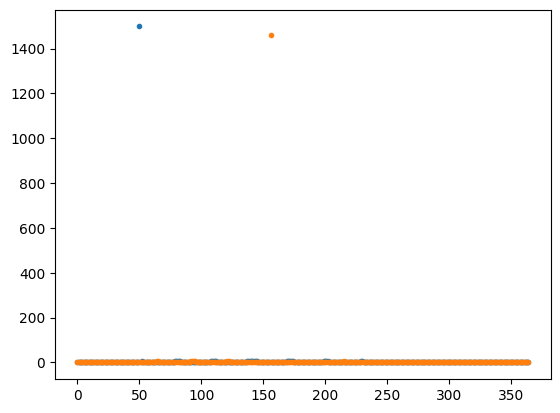

In [ ]:
# 1421/60
import matplotlib.pyplot as plt
plt.plot(df['Moonrise Error (min)'],'.')
plt.plot(df['Moonset Error (min)'],'.')
plt.show()

In [ ]:
df.describe()

,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
count,365.000000,365.000000,365.000000
mean,6.654274,6.472329,0.001756
std,78.300885,76.224411,0.001356
min,0.020000,0.020000,0.000000
25%,1.500000,1.430000,0.001000
50%,2.750000,2.700000,0.001000
75%,3.520000,3.580000,0.002000
max,1498.280000,1458.550000,0.006000


In [ ]:
import numpy as np
np.percentile(df['Moonrise Error (min)'],np.arange(1,100,1))

array([0.0628, 0.1084, 0.17  , 0.25  , 0.32  , 0.3468, 0.4248, 0.52  ,
       0.5604, 0.632 , 0.7008, 0.7572, 0.8064, 0.83  , 0.988 , 1.05  ,
       1.07  , 1.1104, 1.1364, 1.196 , 1.23  , 1.2724, 1.3588, 1.4108,
       1.5   , 1.5428, 1.5728, 1.6668, 1.7256, 1.85  , 1.92  , 1.9248,
       1.9524, 2.0104, 2.05  , 2.1008, 2.15  , 2.18  , 2.2192, 2.242 ,
       2.3348, 2.3976, 2.4404, 2.4832, 2.516 , 2.5744, 2.6016, 2.6644,
       2.7072, 2.75  , 2.77  , 2.8   , 2.82  , 2.8612, 2.9   , 2.9888,
       3.0248, 3.0712, 3.1   , 3.12  , 3.15  , 3.1636, 3.18  , 3.2   ,
       3.226 , 3.2348, 3.25  , 3.28  , 3.32  , 3.328 , 3.3588, 3.3816,
       3.45  , 3.4736, 3.52  , 3.5428, 3.58  , 3.646 , 3.6756, 3.706 ,
       3.7784, 3.82  , 3.836 , 3.9104, 3.946 , 3.98  , 4.034 , 4.1232,
       4.1796, 4.318 , 4.382 , 4.4764, 4.5404, 4.578 , 4.7   , 4.78  ,
       4.8224, 4.93  , 5.08  ])

In [ ]:
np.percentile(df['Moonset Error (min)'],np.arange(1,100,1))

array([0.0628, 0.1228, 0.13  , 0.1912, 0.284 , 0.33  , 0.3748, 0.47  ,
       0.5   , 0.546 , 0.6308, 0.7136, 0.7564, 0.8296, 0.888 , 0.9348,
       0.9764, 1.07  , 1.1532, 1.196 , 1.2244, 1.2708, 1.33  , 1.3572,
       1.43  , 1.5584, 1.6356, 1.696 , 1.7756, 1.82  , 1.8284, 1.85  ,
       1.8736, 1.9152, 1.98  , 2.0204, 2.0572, 2.096 , 2.1692, 2.22  ,
       2.2848, 2.32  , 2.3604, 2.4364, 2.5   , 2.5332, 2.5816, 2.6   ,
       2.6736, 2.7   , 2.75  , 2.8556, 2.8792, 2.9412, 2.976 , 3.    ,
       3.0396, 3.07  , 3.07  , 3.13  , 3.15  , 3.15  , 3.17  , 3.1796,
       3.22  , 3.2348, 3.25  , 3.27  , 3.2832, 3.32  , 3.3588, 3.3816,
       3.4272, 3.518 , 3.58  , 3.58  , 3.62  , 3.63  , 3.6412, 3.65  ,
       3.67  , 3.7492, 3.8024, 3.83  , 3.85  , 3.88  , 3.8936, 3.92  ,
       3.93  , 3.988 , 4.05  , 4.0976, 4.1252, 4.1716, 4.266 , 4.28  ,
       4.3024, 4.48  , 4.6092])

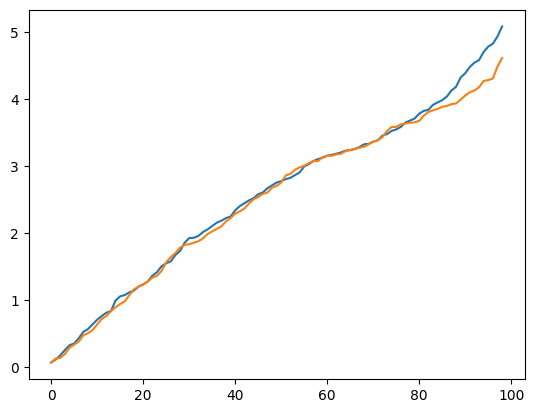

In [ ]:
plt.plot(np.percentile(df['Moonrise Error (min)'],np.arange(1,100,1)))
plt.plot(np.percentile(df['Moonset Error (min)'],np.arange(1,100,1)))
plt.show()

In [ ]:
df.head()

,Date,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
0,2025-01-01,0.72,1.43,0.000
1,2025-01-02,1.40,0.13,0.001
2,2025-01-03,1.92,1.07,0.003
3,2025-01-04,2.23,2.08,0.004
4,2025-01-05,2.45,2.75,0.005


In [ ]:
# df.tail()

In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER YEAR (Jan. 1st) from  1950 to 2050
#        MOONRISE - MOONSET & MOON ILUMINATION
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------


ts = load.timescale()
eph = load("de440.bsp")
# eph = load("de440s.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]



results = []

for y in range(1950, 2051):

    m=1
    d=1
    date = datetime(y, m, d)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================
    ss_moon = solarsystem.Moon(year=y, month=m, day=d, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)
    ss_illum = ss_moon.phase()
    ss_moonrise, ss_moonset = ss_moon.moonriseset()

    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)


    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    location = wgs84.latlon(LATITUDE , LONGITUDE )

    observer = eph['Earth'] + location

    moon = eph['Moon']
    t0 = ts.utc(y, m, d-1)
    t1 = ts.utc(y, m, d+1)
    # t0 = ts.utc(y, m, d)-timedelta(days=1)
    # t1 = ts.utc(y, m, d)+timedelta(days=1)

    t, y0 = almanac.find_risings(observer, moon, t0, t1)

    if len(t.utc_strftime())==2:
        sf_moonrise = t.utc_strftime()[1][:-4]
    else:
        sf_moonrise = t.utc_strftime()[0][:-4]

    sf_moonrise=datetime.strptime(sf_moonrise, "%Y-%m-%d %H:%M:%S")

    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d)+timedelta(days=2)
    t, y0 = almanac.find_settings(observer, moon, t0, t1)
    sf_moonset=t.utc_strftime()[0][:-4]
    sf_moonset=datetime.strptime(sf_moonset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)

    # # ==========================================
    # # skyfield illumination
    # # ==========================================

    sf_illum=almanac.fraction_illuminated(eph, 'moon', t=ts.utc(y, m, d, 12))


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_moonrise and sf_moonrise:
        # print(date,ss_moonrise, sf_moonrise)
        # rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        rise_err = minutes_abs_difference(ss_moonrise, sf_moonrise)

    if ss_moonset and sf_moonset:
        # print(date,ss_moonset, sf_moonset)
        # set_err = minutes_difference(ss_moonset, sf_moonset)
        set_err = minutes_abs_difference(ss_moonset, sf_moonset)

    illum_err = abs(ss_illum - sf_illum)

    results.append({
        "Date": date.date(),
        "Moonrise Error (min)": round(rise_err, 2),
        "Moonset Error (min)": round(set_err, 2),
        "Illumination Error (%)": round(illum_err, 3)
    })
df = pd.DataFrame(results)

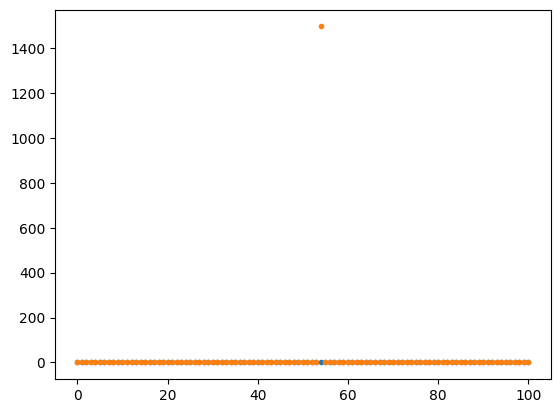

In [ ]:
plt.plot(df['Moonrise Error (min)'],'.')
plt.plot(df['Moonset Error (min)'],'.')
plt.show()

In [ ]:
df.describe()

,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
count,101.000000,101.000000,101.000000
mean,2.249109,16.983069,0.002594
std,1.074743,148.636451,0.001945
min,0.000000,0.100000,0.000000
25%,1.420000,1.150000,0.001000
50%,2.330000,2.320000,0.003000
75%,3.220000,3.170000,0.004000
max,3.920000,1495.930000,0.006000


In [ ]:
# 2025
# Moonrise Error (min) 	Moonset Error (min) 	Illumination Error (%)
#     25% 50% 75%            25% 50% 75%             mean max std
#    1.50 2.75 3.52 	      1.43 2.70 3.58 	      0.18 0.60 0.14

# 1950-2050
# Moonrise Error (min) 	Moonset Error (min) 	Illumination Error (%)
#     25% 50% 75%            25% 50% 75%             mean max std
#    1.42 2.33 3.22 	      1.15 2.32 3.17 	      0.26 0.60 0.19

In [ ]:
np.percentile(df['Moonrise Error (min)'],np.arange(1,100,1))

array([0.23, 0.25, 0.27, 0.35, 0.4 , 0.52, 0.55, 0.55, 0.63, 0.67, 0.72,
       0.72, 0.77, 0.85, 0.87, 1.03, 1.03, 1.08, 1.17, 1.18, 1.2 , 1.23,
       1.37, 1.4 , 1.42, 1.43, 1.47, 1.5 , 1.58, 1.68, 1.7 , 1.73, 1.77,
       1.78, 1.85, 1.88, 1.95, 1.97, 2.02, 2.02, 2.05, 2.05, 2.08, 2.1 ,
       2.1 , 2.12, 2.17, 2.22, 2.23, 2.33, 2.33, 2.37, 2.5 , 2.53, 2.62,
       2.63, 2.68, 2.7 , 2.72, 2.73, 2.75, 2.77, 2.78, 2.85, 2.87, 3.  ,
       3.12, 3.12, 3.17, 3.18, 3.2 , 3.2 , 3.2 , 3.22, 3.22, 3.23, 3.23,
       3.25, 3.27, 3.27, 3.28, 3.28, 3.32, 3.33, 3.37, 3.38, 3.43, 3.45,
       3.47, 3.52, 3.57, 3.58, 3.6 , 3.67, 3.72, 3.77, 3.8 , 3.87, 3.88])

In [ ]:
np.percentile(df['Moonset Error (min)'],np.arange(1,100,1))

array([0.1 , 0.33, 0.38, 0.42, 0.47, 0.47, 0.55, 0.57, 0.58, 0.62, 0.67,
       0.68, 0.7 , 0.7 , 0.77, 0.77, 0.83, 0.9 , 0.9 , 0.92, 1.02, 1.07,
       1.1 , 1.12, 1.15, 1.27, 1.43, 1.43, 1.45, 1.48, 1.55, 1.65, 1.68,
       1.75, 1.78, 1.82, 1.83, 1.93, 1.95, 1.97, 2.  , 2.02, 2.08, 2.1 ,
       2.2 , 2.22, 2.25, 2.27, 2.28, 2.32, 2.35, 2.35, 2.42, 2.48, 2.53,
       2.53, 2.58, 2.62, 2.65, 2.72, 2.72, 2.73, 2.77, 2.78, 2.83, 2.87,
       2.88, 2.88, 2.95, 3.02, 3.1 , 3.12, 3.12, 3.15, 3.17, 3.18, 3.23,
       3.25, 3.27, 3.28, 3.28, 3.3 , 3.35, 3.38, 3.38, 3.42, 3.42, 3.58,
       3.62, 3.72, 3.72, 3.73, 3.75, 3.82, 3.83, 3.92, 3.98, 3.98, 4.05])

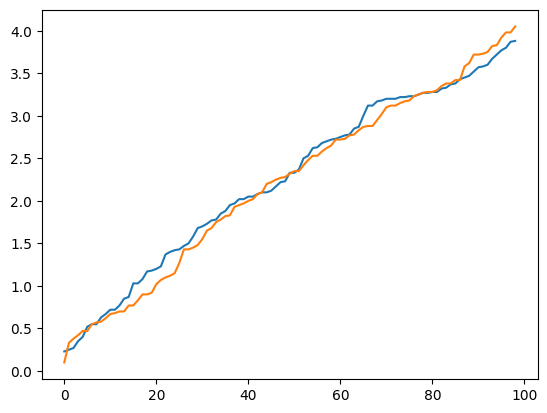

In [ ]:
plt.plot(np.percentile(df['Moonrise Error (min)'],np.arange(1,100,1)))
plt.plot(np.percentile(df['Moonset Error (min)'],np.arange(1,100,1)))
plt.show()

In [ ]:
# df.head()

In [ ]:
df.tail()

,Date,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
96,2046-01-01,3.47,3.25,0.004
97,2047-01-01,1.73,1.68,0.005
98,2048-01-01,1.70,0.10,0.000
99,2049-01-01,3.43,3.82,0.001
100,2050-01-01,3.25,3.28,0.005


In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER YEAR (Jan. 1st) from  1950 to 2050
#        MOONRISE - MOONSET & MOON ILUMINATION
# ***************** topographic=True *********************
# Metric: MAE (Mean Error - NOT absolute)
# ------------------------------------------------------------

ts = load.timescale()
eph = load("de440.bsp")
# eph = load("de440s.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]



results = []

for y in range(1950, 2051):

    m=1
    d=1
    date = datetime(y, m, d)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================

    ss_moon = solarsystem.Moon(year=y, month=m, day=d, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)
    ss_illum = ss_moon.phase()
    ss_moonrise, ss_moonset = ss_moon.moonriseset()

    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)


    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    location = wgs84.latlon(LATITUDE , LONGITUDE )

    observer = eph['Earth'] + location

    moon = eph['Moon']
    t0 = ts.utc(y, m, d-1)
    t1 = ts.utc(y, m, d+1)
    # t0 = ts.utc(y, m, d)-timedelta(days=1)
    # t1 = ts.utc(y, m, d)+timedelta(days=1)

    t, y0 = almanac.find_risings(observer, moon, t0, t1)

    if len(t.utc_strftime())==2:
        sf_moonrise = t.utc_strftime()[1][:-4]
    else:
        sf_moonrise = t.utc_strftime()[0][:-4]

    sf_moonrise=datetime.strptime(sf_moonrise, "%Y-%m-%d %H:%M:%S")

    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d)+timedelta(days=2)
    t, y0 = almanac.find_settings(observer, moon, t0, t1)
    sf_moonset=t.utc_strftime()[0][:-4]
    sf_moonset=datetime.strptime(sf_moonset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)

    # # ==========================================
    # # skyfield illumination
    # # ==========================================

    sf_illum=almanac.fraction_illuminated(eph, 'moon', t=ts.utc(y, m, d, 12))


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_moonrise and sf_moonrise:
        # print(date,ss_moonrise, sf_moonrise)
        rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        # rise_err = minutes_abs_difference(ss_moonrise, sf_moonrise)

    if ss_moonset and sf_moonset:
        # print(date,ss_moonset, sf_moonset)
        set_err = minutes_difference(ss_moonset, sf_moonset)
        # set_err = minutes_abs_difference(ss_moonset, sf_moonset)

    illum_err = abs(ss_illum - sf_illum)

    results.append({
        "Date": date.date(),
        "Moonrise Error (min)": round(rise_err, 2),
        "Moonset Error (min)": round(set_err, 2),
        "Illumination Error (%)": round(illum_err, 3)
    })

df = pd.DataFrame(results)

In [ ]:
df.describe()

,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
count,101.000000,101.000000,101.000000
mean,0.360594,-15.323861,0.002594
std,2.476453,148.818462,0.001945
min,-3.720000,-1495.930000,0.000000
25%,-1.970000,-2.620000,0.001000
50%,0.850000,-0.830000,0.003000
75%,2.500000,1.680000,0.004000
max,3.920000,3.420000,0.006000


In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY FOR A SINGLE YEAR
#        MOONRISE - MOONSET & MOON ILUMINATION
# ***************** topographic=True *********************
# Metric: MAE (Mean Error - NOT ABSOLUTE)
# ------------------------------------------------------------


ts = load.timescale()
eph = load("de440.bsp")
# eph = load("de440s.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]


results = []

for i in range(N_DAYS):

    date = datetime(YEAR, MONTH, DAY) + timedelta(days=i)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================
    # is_dst=0
    # if (m>3)&(m<10):
    #     is_dst = 1
    # if ((m==3)&(d>dst_starts))|((m==10)&(d<dst_ends)):
    #     is_dst = 1

    ss_moon = solarsystem.Moon(year=y, month=m, day=d, hour=12, minute=0,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE, topographic=True)

    ss_illum = ss_moon.phase()
    ss_moonrise, ss_moonset = ss_moon.moonriseset()

    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)


    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    # bluffton = wgs84.latlon(LATITUDE * N, LONGITUDE * E)
    location = wgs84.latlon(LATITUDE , LONGITUDE )
    # bluffton = wgs84.latlon(LATITUDE , LONGITUDE, elevation_m=-6500000 )

    observer = eph['Earth'] + location


    moon = eph['Moon']
    t0 = ts.utc(y, m, d-1)
    t1 = ts.utc(y, m, d+1)
    # t0 = ts.utc(y, m, d)-timedelta(days=1)
    # t1 = ts.utc(y, m, d)+timedelta(days=1)

    t, y0 = almanac.find_risings(observer, moon, t0, t1)
    # print('Moonrises (UTC):', t.utc_iso(' '))

    if len(t.utc_strftime())==2:
        sf_moonrise = t.utc_strftime()[1][:-4]
    else:
        sf_moonrise = t.utc_strftime()[0][:-4]

    sf_moonrise=datetime.strptime(sf_moonrise, "%Y-%m-%d %H:%M:%S")

    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d)+timedelta(days=2)
    t, y0 = almanac.find_settings(observer, moon, t0, t1)
    # print('Moonsets (UTC):', t.utc_iso(' '))
    sf_moonset=t.utc_strftime()[0][:-4]
    sf_moonset=datetime.strptime(sf_moonset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)

    # # ==========================================
    # # skyfield illumination
    # # ==========================================

    # phase = almanac.moon_phase(eph, t0)
    sf_illum=almanac.fraction_illuminated(eph, 'moon', t=ts.utc(y, m, d, 12))
    # print(sf_illum)


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_moonrise and sf_moonrise:
        # print(date,ss_moonrise, sf_moonrise)
        rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        # rise_err = minutes_abs_difference(ss_moonrise, sf_moonrise)

    if ss_moonset and sf_moonset:
        # print(date,ss_moonset, sf_moonset)
        set_err = minutes_difference(ss_moonset, sf_moonset)
        # set_err = minutes_abs_difference(ss_moonset, sf_moonset)

    illum_err = abs(ss_illum - sf_illum)


    results.append({
        "Date": date.date(),
        "Moonrise Error (min)": round(rise_err, 2),
        "Moonset Error (min)": round(set_err, 2),
        "Illumination Error (%)": round(illum_err, 3)
    })

# --------------------------------------------------
# RESULTS
# --------------------------------------------------

df = pd.DataFrame(results)

print("\nMoon Validation Against Skyfield / JPL DE440\n")
# print(df.to_string(index=False))

df.to_csv("moon_validation.csv", index=False)

print("\nSaved to moon_validation.csv")


Moon Validation Against Skyfield / JPL DE440


Saved to moon_validation.csv


In [ ]:
df.describe()

,Moonrise Error (min),Moonset Error (min),Illumination Error (%)
count,365.000000,365.000000,365.000000
mean,3.754384,-3.714466,0.001756
std,78.493920,76.408977,0.001356
min,-5.150000,-1458.550000,0.000000
25%,-3.100000,-2.320000,0.001000
50%,-0.270000,0.420000,0.001000
75%,2.450000,3.000000,0.002000
max,1498.280000,4.800000,0.006000


In [ ]:
YEAR,N_DAYS

(2025, 365)

## SUNRISE - SUNSET

In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY FOR A SINGLE YEAR
#               SUNRISE - SUNSET
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------

ts = load.timescale()
eph = load("de440.bsp")
# eph = load("de440s.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]


results = []

for i in range(N_DAYS):

    date = datetime(YEAR, MONTH, DAY) + timedelta(days=i)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================

    ss_sun = solarsystem.Sunriseset(year=y, month=m, day=d,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE)
    ss_sunrise, ss_sunset = ss_sun.riseset()

    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)



    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    location = wgs84.latlon(LATITUDE , LONGITUDE )

    observer = eph['Earth'] + location

    sun = eph['Sun']
    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d+1)

    t, y0 = almanac.find_risings(observer, sun, t0, t1)
    sf_sunrise = t.utc_strftime()[0][:-4]
    sf_sunrise=datetime.strptime(sf_sunrise, "%Y-%m-%d %H:%M:%S")

    t, y0 = almanac.find_settings(observer, sun, t0, t1)
    sf_sunset=t.utc_strftime()[0][:-4]
    sf_sunset=datetime.strptime(sf_sunset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_sunrise and sf_sunrise:
        # print(date,ss_sunrise, sf_sunrise)
        # rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        rise_err = minutes_abs_difference(ss_sunrise, sf_sunrise)

    if ss_sunset and sf_sunset:
        # print(date,ss_moonset, sf_moonset)
        # set_err = minutes_difference(ss_moonset, sf_moonset)
        set_err = minutes_abs_difference(ss_sunset, sf_sunset)


    results.append({
        "Date": date.date(),
        "Sunrise Error (min)": round(rise_err, 2),
        "Sunset Error (min)": round(set_err, 2) ,
    })
df = pd.DataFrame(results)

In [ ]:
df.describe()

,Sunrise Error (min),Sunset Error (min)
count,365.000000,365.000000
mean,0.271973,0.153068
std,0.125521,0.075538
min,0.000000,0.000000
25%,0.200000,0.120000
50%,0.270000,0.150000
75%,0.330000,0.180000
max,0.520000,0.300000


In [ ]:
# ------------------------------------------------------------
# COMPARISON - ONCE PER DAY (Jan 1st) from 1950 to 2050
#               SUNRISE - SUNSET
# ***************** topographic=True *********************
# Metric: MAE (Mean Absolute Error)
# ------------------------------------------------------------

ts = load.timescale()
eph = load("de440.bsp")

earth = eph["earth"]
moon = eph["moon"]
sun = eph["sun"]


results = []

for y in range(1950, 2051):

    m=1
    d=1
    date = datetime(y, m, d)

    y = date.year
    m = date.month
    d = date.day


    # ==========================================
    # solarsystem
    # ==========================================

    ss_sun = solarsystem.Sunriseset(year=y, month=m, day=d,
                         UT=0, dst=0, longtitude=LONGITUDE, latitude=LATITUDE)
    ss_sunrise, ss_sunset = ss_sun.riseset()


    # ss_moonrise = ss_moonrise+timedelta(minutes=3)
    # ss_moonset = ss_moonset+timedelta(minutes=3)


    # # ==========================================
    # # skyfield moonrise/set
    # # ==========================================

    location = wgs84.latlon(LATITUDE , LONGITUDE )

    observer = eph['Earth'] + location

    sun = eph['Sun']
    t0 = ts.utc(y, m, d)
    t1 = ts.utc(y, m, d+1)

    t, y0 = almanac.find_risings(observer, sun, t0, t1)

    sf_sunrise = t.utc_strftime()[0][:-4]
    sf_sunrise=datetime.strptime(sf_sunrise, "%Y-%m-%d %H:%M:%S")

    t, y0 = almanac.find_settings(observer, sun, t0, t1)
    sf_sunset=t.utc_strftime()[0][:-4]
    sf_sunset=datetime.strptime(sf_sunset, "%Y-%m-%d %H:%M:%S")

    # sf_moonrise = sf_moonrise-timedelta(minutes=3)
    # sf_moonset = sf_moonset-timedelta(minutes=3)


    # ==========================================
    # errors
    # ==========================================

    rise_err = None
    set_err = None

    if ss_sunrise and sf_sunrise:
        # print(date,ss_moonrise, sf_moonrise)
        # rise_err = minutes_difference(ss_moonrise, sf_moonrise)
        rise_err = minutes_abs_difference(ss_sunrise, sf_sunrise)

    if ss_sunset and sf_sunset:
        # print(date,ss_moonset, sf_moonset)
        # set_err = minutes_difference(ss_moonset, sf_moonset)
        set_err = minutes_abs_difference(ss_sunset, sf_sunset)


    results.append({
        "Date": date.date(),
        "Sunrise Error (min)": round(rise_err, 2),
        "Sunset Error (min)": round(set_err, 2) ,
    })
df = pd.DataFrame(results)

In [ ]:
df.describe()

,Sunrise Error (min),Sunset Error (min)
count,101.000000,101.000000
mean,0.059010,0.089307
std,0.067993,0.027065
min,0.000000,0.020000
25%,0.020000,0.080000
50%,0.030000,0.100000
75%,0.050000,0.100000
max,0.250000,0.150000
